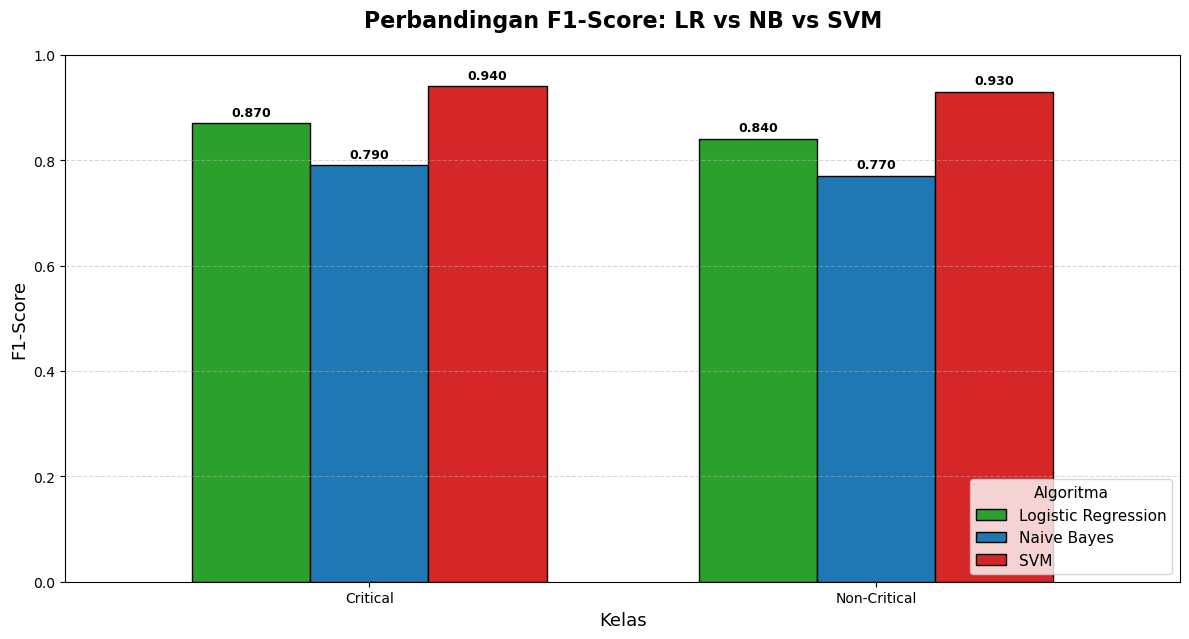

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. DATA F1-SCORE 
# Data F1-Score untuk Logistic Regression (LR)
f1_lr_critical = 0.87
f1_lr_non_critical = 0.84

# Data F1-Score untuk Naive Bayes (NB)
f1_nb_critical = 0.79 
f1_nb_non_critical = 0.77 

# Data F1-Score untuk SVM
f1_svm_critical = 0.94
f1_svm_non_critical = 0.93

# 2. STRUKTURISASI DATA UNTUK PENGGAMBARAN
data_per_kelas = {
    'Kelas': ['Critical', 'Non-Critical'],
    'Logistic Regression': [f1_lr_critical, f1_lr_non_critical],
    'Naive Bayes': [f1_nb_critical, f1_nb_non_critical],
    'SVM': [f1_svm_critical, f1_svm_non_critical]
}

# DataFrame baru
df_per_kelas = pd.DataFrame(data_per_kelas)
df_per_kelas_plot = df_per_kelas.set_index('Kelas')

# 3. PROSES VISUALISASI
fig, ax = plt.subplots(figsize=(12, 6.5))

df_per_kelas_plot.plot(kind='bar', ax=ax, rot=0, 
                       color=['#2ca02c', '#1f77b4', '#d62728'], # Hijau, Biru, Merah
                       edgecolor='black', width=0.7)

# Judul
plt.title('Perbandingan F1-Score: LR vs NB vs SVM', fontsize=16, pad=20, fontweight='bold')

# Sumbu Y
plt.ylabel('F1-Score', fontsize=13)

# Sumbu X 
plt.xlabel('Kelas', fontsize=13)
# Sumbu Y diset dari 0 sampai 1
plt.ylim(0, 1.0)
# Tambahkan grid horizontal putus-putus
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tampilkan legenda di pojok kanan bawah
plt.legend(title='Algoritma', loc='lower right', fontsize=11, title_fontsize=11)

# Menambahkan angka di atas batang
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), # Jarak teks ke atas batang
                textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.tight_layout()

plt.savefig('../reports/f1_score_comparison_grouped.png', dpi=300)

plt.show()

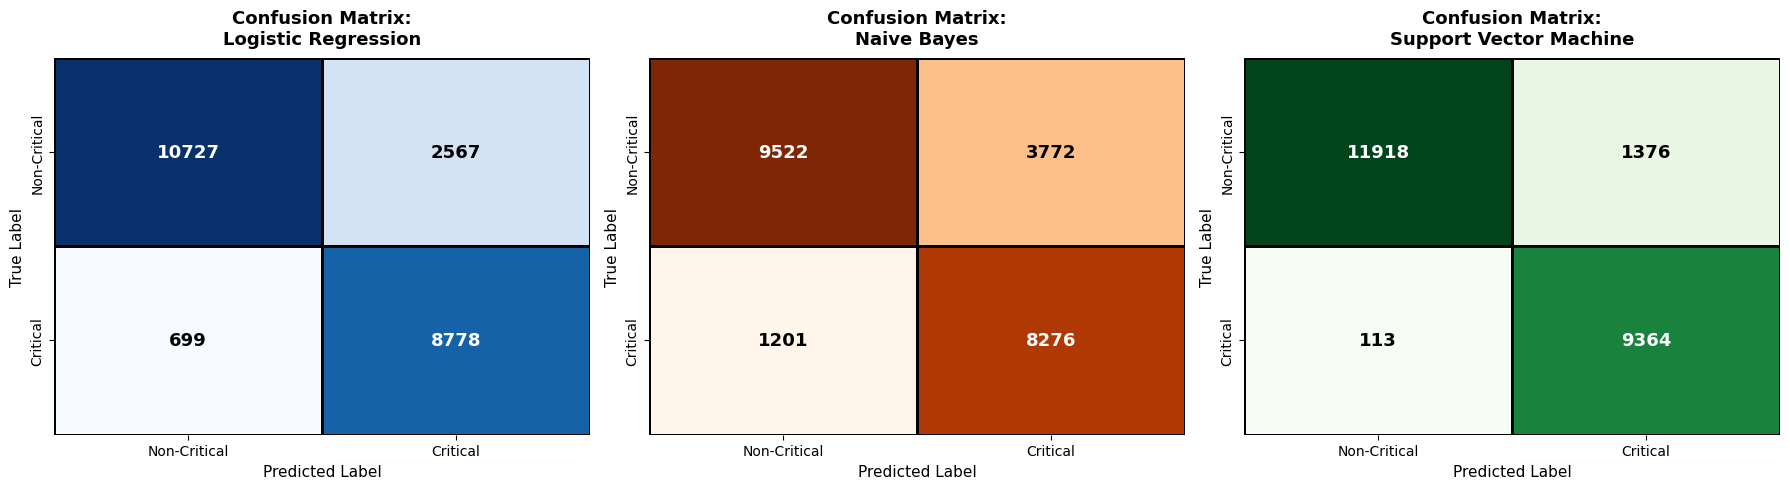

PERBANDINGAN CONFUSION MATRIX: LOGISTIC REGRESSION vs NAIVE BAYES vs SVM

--- LOGISTIC REGRESSION ---
Confusion Matrix:
[[10727  2567]
 [  699  8778]]
True Negatives (TN):  10727
False Positives (FP): 2567
False Negatives (FN): 699
True Positives (TP):  8778

Accuracy:  0.8566
Precision: 0.7737
Recall:    0.9262

--- NAIVE BAYES ---
Confusion Matrix:
[[9522 3772]
 [1201 8276]]
True Negatives (TN):  9522
False Positives (FP): 3772
False Negatives (FN): 1201
True Positives (TP):  8276

Accuracy:  0.7816
Precision: 0.6869
Recall:    0.8733

--- SUPPORT VECTOR MACHINE (SVM) ---
Confusion Matrix:
[[11918  1376]
 [  113  9364]]
True Negatives (TN):  11918
False Positives (FP): 1376
False Negatives (FN): 113
True Positives (TP):  9364

Accuracy:  0.9346
Precision: 0.8719
Recall:    0.9881

PERBANDINGAN RINGKAS
                 Model Accuracy Precision Recall
   LOGISTIC REGRESSION   0.8566    0.7737 0.9262
           NAIVE BAYES   0.7816    0.6869 0.8733
SUPPORT VECTOR MACHINE   0.9346    0.8

In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================================================
# PERBANDINGAN CONFUSION MATRIX: LOGISTIC REGRESSION vs NAIVE BAYES vs SVM
# =========================================================

# Load Data
with open('../data/processed/data_splits_tfidf.pkl', 'rb') as f:
    data_splits = pickle.load(f)
X_test = data_splits['X_test']
y_test = data_splits['y_test']

# Load Models
with open('../data/processed/model_lr_tuned_biner.pkl', 'rb') as f:
    model_lr = pickle.load(f)
with open('../data/processed/model_nb_biner.pkl', 'rb') as f:
    model_nb = pickle.load(f)
with open('../data/processed/model_svm_biner.pkl', 'rb') as f:
    model_svm = pickle.load(f)

# Prediksi
y_pred_lr = model_lr.predict(X_test)
y_pred_nb = model_nb.predict(X_test)
y_pred_svm = model_svm.predict(X_test)

# Hitung Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Label mapping
labels_map = ['Non-Critical', 'Critical']

# =========================================================
# VISUALISASI CONFUSION MATRIX UNTUK 3 MODEL
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Daftar models, confusion matrices, colormaps, dan titles
models_info = [
    ('LR', cm_lr, 'Blues', axes[0]),
    ('NB', cm_nb, 'Oranges', axes[1]),
    ('SVM', cm_svm, 'Greens', axes[2])
]

for model_name, cm, cmap, ax in models_info:
    # Buat heatmap tanpa annotation
    sns.heatmap(cm, 
                annot=False,
                fmt='d',
                cmap=cmap,
                xticklabels=labels_map,
                yticklabels=labels_map,
                ax=ax,
                cbar=False,
                linewidths=2,
                linecolor='black')

    # Tambahkan teks manual dengan warna kontras otomatis
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > thresh else "black"
            ax.text(j + 0.5, i + 0.5, 
                    f'{cm[i, j]}',
                    ha='center', va='center',
                    color=color,
                    fontsize=13, fontweight='bold')

    # Labels untuk setiap model
    if model_name == 'LR':
        full_name = 'Logistic Regression'
    elif model_name == 'NB':
        full_name = 'Naive Bayes'
    else:
        full_name = 'Support Vector Machine'
    
    ax.set_title(f'Confusion Matrix:\n{full_name}', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Cetak Ringkasan Metrics
print("=" * 100)
print("PERBANDINGAN CONFUSION MATRIX: LOGISTIC REGRESSION vs NAIVE BAYES vs SVM")
print("=" * 100)

metrics_list = []

models_detail = [
    ('LOGISTIC REGRESSION', cm_lr, y_pred_lr),
    ('NAIVE BAYES', cm_nb, y_pred_nb),
    ('SUPPORT VECTOR MACHINE (SVM)', cm_svm, y_pred_svm)
]

for model_name, cm, y_pred in models_detail:
    print(f"\n--- {model_name} ---")
    print(f"Confusion Matrix:\n{cm}")
    tn, fp, fn, tp = cm.ravel()
    print(f"True Negatives (TN):  {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Positives (TP):  {tp}")

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"\nAccuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    
    metrics_list.append({
        'Model': model_name.split('(')[0].strip(),
        'Accuracy': f"{accuracy:.4f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}"
    })

print("\n" + "=" * 100)
print("PERBANDINGAN RINGKAS")
print("=" * 100)
comparison_df = pd.DataFrame(metrics_list)
print(comparison_df.to_string(index=False))
print("=" * 100)

MENGHITUNG LEARNING CURVE: LOGISTIC REGRESSION

MENGHITUNG LEARNING CURVE: NAIVE BAYES

MENGHITUNG LEARNING CURVE: SUPPORT VECTOR MACHINE (SVM)


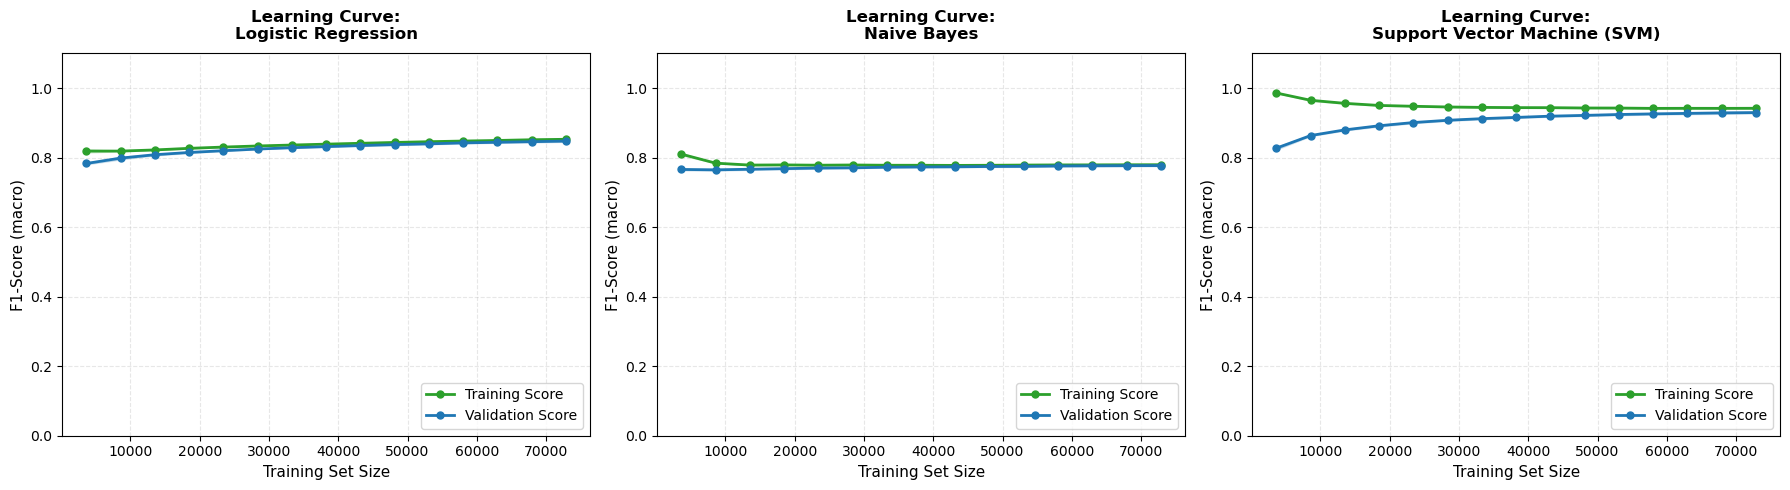


Learning curve berhasil dibuat dan disimpan ke: ../reports/learning_curve_comparison.png


In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# =========================================================
# LEARNING CURVE: LOGISTIC REGRESSION vs NAIVE BAYES vs SVM
# =========================================================

# Load Data
with open('../data/processed/data_splits_tfidf.pkl', 'rb') as f:
    data_splits = pickle.load(f)
X_train = data_splits['X_train']
y_train = data_splits['y_train']

# Load Models
with open('../data/processed/model_lr_tuned_biner.pkl', 'rb') as f:
    model_lr = pickle.load(f)
with open('../data/processed/model_nb_biner.pkl', 'rb') as f:
    model_nb = pickle.load(f)
with open('../data/processed/model_svm_biner.pkl', 'rb') as f:
    model_svm = pickle.load(f)

# =========================================================
# FUNGSI UNTUK PLOT LEARNING CURVE
# =========================================================
def plot_learning_curves(estimator, X, y, title, ax, cv=5, train_sizes=None):
    """
    Plot learning curve untuk suatu model
    """
    if train_sizes is None:
        train_sizes = np.linspace(0.1, 1.0, 10)
    
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, 
        cv=cv, 
        train_sizes=train_sizes,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )
    
    # Hitung mean dan std
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    # Plot
    ax.plot(train_sizes, train_mean, 'o-', color='#2ca02c', label='Training Score', linewidth=2, markersize=5)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#2ca02c')
    
    ax.plot(train_sizes, val_mean, 'o-', color='#1f77b4', label='Validation Score', linewidth=2, markersize=5)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#1f77b4')
    
    ax.set_xlabel('Training Set Size', fontsize=11)
    ax.set_ylabel('F1-Score (macro)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.1])

# =========================================================
# PLOTTING LEARNING CURVES UNTUK 3 MODEL
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Definisi train_sizes untuk konsistensi
train_sizes = np.linspace(0.05, 1.0, 15)

# --- Logistic Regression ---
print("=" * 80)
print("MENGHITUNG LEARNING CURVE: LOGISTIC REGRESSION")
print("=" * 80)
plot_learning_curves(model_lr, X_train, y_train, 
                     'Learning Curve:\nLogistic Regression',
                     axes[0], cv=5, train_sizes=train_sizes)

# --- Naive Bayes ---
print("\nMENGHITUNG LEARNING CURVE: NAIVE BAYES")
print("=" * 80)
plot_learning_curves(model_nb, X_train, y_train,
                     'Learning Curve:\nNaive Bayes',
                     axes[1], cv=5, train_sizes=train_sizes)

# --- SVM ---
print("\nMENGHITUNG LEARNING CURVE: SUPPORT VECTOR MACHINE (SVM)")
print("=" * 80)
plot_learning_curves(model_svm, X_train, y_train,
                     'Learning Curve:\nSupport Vector Machine (SVM)',
                     axes[2], cv=5, train_sizes=train_sizes)

plt.tight_layout()
plt.savefig('../reports/learning_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("Learning curve berhasil dibuat dan disimpan ke: ../reports/learning_curve_comparison.png")
print("=" * 80)